# 🔍 Exploratory Analysis Notebook
## Smoking Status Prediction — Person 1: Data Analysis
**Purpose:** Organized draft exploring all 10 features through Univariate, Bivariate, and Multivariate analyses.


## 0. Setup & Dataset Generation

In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Notebook-wide style ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 5)})

print(" Libraries loaded successfully")


 Libraries loaded successfully


In [ ]:
# ── Fill in your student IDs ─────────────────────────────────────────────────
id_1 = 8657   # ← change
id_2 = 8881   # ← change
id_3 = 8962   # ← change (leave 0000 if team of 2)

random_seed   = id_1 + id_2 + id_3
random.seed(random_seed)

data_path   = "data.csv"        # ← path to original data
output_path = "your_data.csv"   # ← generated variant

all_data      = pd.read_csv(data_path)
all_columns   = all_data.columns.tolist()
target_column = "smoking"
all_columns.remove(target_column)

selected_columns = random.sample(all_columns, 10)
print("Selected features:", selected_columns)   

selected_columns_with_target = np.append(selected_columns, target_column)
df = all_data[selected_columns_with_target].copy()
df.to_csv(output_path, index=False)
print(f"\n Dataset saved to '{output_path}'  |  Shape: {df.shape}")


Selected features: ['eyesight(right)', 'ALT', 'triglyceride', 'fasting blood sugar', 'LDL', 'waist(cm)', 'hearing(right)', 'AST', 'hearing(left)', 'Cholesterol']

 Dataset saved to 'your_data.csv'  |  Shape: (159256, 11)


In [ ]:
# ── Train / Validation / Test split 
df = pd.read_csv(output_path)

X = df.drop(columns=["smoking"])
y = df["smoking"]

# 70 % train | 15 % val | 15 % test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Save splits to CSV files for later use
X_train.assign(smoking=y_train).to_csv("train.csv", index=False)
X_val.assign(smoking=y_val).to_csv("val.csv",   index=False)
X_test.assign(smoking=y_test).to_csv("test.csv",  index=False)

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")
print(" Splits saved: train.csv, val.csv, test.csv")

FEATURES = X.columns.tolist()


Train : (111479, 10)  |  Val : (23888, 10)  |  Test : (23889, 10)
 Splits saved: train.csv, val.csv, test.csv


## 1. Quick Data Overview

In [4]:
print("Shape:", df.shape)
df.head()


Shape: (159256, 11)


,eyesight(right),ALT,triglyceride,fasting blood sugar,LDL,waist(cm),hearing(right),AST,hearing(left),Cholesterol,smoking
0,0.6,25,300,94,75,81.0,1,22,1,172,1
1,0.7,23,55,147,126,89.0,2,27,2,194,0
2,0.5,31,197,79,93,81.0,1,27,1,178,1
3,1.2,27,203,91,102,105.0,1,20,1,180,0
4,1.0,13,87,91,93,80.5,1,19,1,155,1


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 159256 entries, 0 to 159255
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   eyesight(right)      159256 non-null  float64
 1   ALT                  159256 non-null  int64  
 2   triglyceride         159256 non-null  int64  
 3   fasting blood sugar  159256 non-null  int64  
 4   LDL                  159256 non-null  int64  
 5   waist(cm)            159256 non-null  float64
 6   hearing(right)       159256 non-null  int64  
 7   AST                  159256 non-null  int64  
 8   hearing(left)        159256 non-null  int64  
 9   Cholesterol          159256 non-null  int64  
 10  smoking              159256 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 13.4 MB


In [6]:
df.describe().round(3)


,eyesight(right),ALT,triglyceride,fasting blood sugar,LDL,waist(cm),hearing(right),AST,hearing(left),Cholesterol,smoking
count,159256.000,159256.000,159256.000,159256.000,159256.000,159256.000,159256.000,159256.000,159256.000,159256.000,159256.000
mean,1.001,26.550,127.616,98.353,114.608,83.002,1.023,25.517,1.024,195.796,0.437
std,0.392,17.753,66.189,15.330,28.159,8.958,0.151,9.465,0.153,28.397,0.496
min,0.100,1.000,8.000,46.000,1.000,51.000,1.000,6.000,1.000,77.000,0.000
25%,0.800,16.000,77.000,90.000,95.000,77.000,1.000,20.000,1.000,175.000,0.000
50%,1.000,22.000,115.000,96.000,114.000,83.000,1.000,24.000,1.000,196.000,0.000
75%,1.200,32.000,165.000,103.000,133.000,89.000,1.000,29.000,1.000,217.000,1.000
max,9.900,2914.000,766.000,375.000,1860.000,127.000,2.000,778.000,2.000,393.000,1.000


In [7]:
# Missing values
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "% Missing": pct})
print(missing_df[missing_df["Missing"] > 0] if missing_df["Missing"].sum() > 0
      else " No missing values found")


 No missing values found


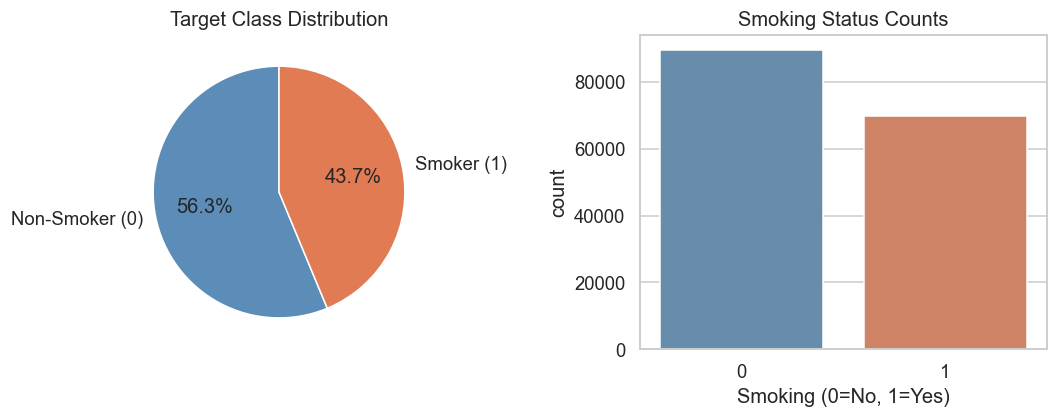

Class balance: {0: 89603, 1: 69653}


In [8]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vc = df["smoking"].value_counts()

axes[0].pie(vc, labels=["Non-Smoker (0)", "Smoker (1)"],
            autopct="%1.1f%%", colors=["#5B8DB8","#E07B54"], startangle=90)
axes[0].set_title("Target Class Distribution")

sns.countplot(x="smoking", data=df, palette=["#5B8DB8","#E07B54"], ax=axes[1])
axes[1].set_title("Smoking Status Counts")
axes[1].set_xlabel("Smoking (0=No, 1=Yes)")

plt.tight_layout()
plt.savefig("fig_target_dist.png", bbox_inches="tight")
plt.show()
print("Class balance:", vc.to_dict())


## 2. Univariate Analysis
Understanding the distribution and characteristics of each individual feature.


In [9]:
# ── 2.1  Descriptive stats table ─────────────────────────────────────────────
num_features = df[FEATURES].select_dtypes(include=np.number).columns.tolist()
cat_features = df[FEATURES].select_dtypes(exclude=np.number).columns.tolist()

stats_df = df[num_features].agg(["mean","median","std","min","max","skew","kurt"]).T
stats_df.columns = ["Mean","Median","Std","Min","Max","Skewness","Kurtosis"]
stats_df = stats_df.round(3)
print("Numerical feature stats:")
stats_df


Numerical feature stats:


,Mean,Median,Std,Min,Max,Skewness,Kurtosis
eyesight(right),1.001,1.0,0.392,0.1,9.9,8.487,192.729
ALT,26.550,22.0,17.753,1.0,2914.0,34.830,4870.242
triglyceride,127.616,115.0,66.189,8.0,766.0,0.986,0.996
fasting blood sugar,98.353,96.0,15.330,46.0,375.0,3.461,27.200
LDL,114.608,114.0,28.159,1.0,1860.0,6.875,323.631
waist(cm),83.002,83.0,8.958,51.0,127.0,0.072,-0.056
hearing(right),1.023,1.0,0.151,1.0,2.0,6.302,37.721
AST,25.517,24.0,9.465,6.0,778.0,11.592,629.519
hearing(left),1.024,1.0,0.153,1.0,2.0,6.224,36.738
Cholesterol,195.796,196.0,28.397,77.0,393.0,0.043,-0.206


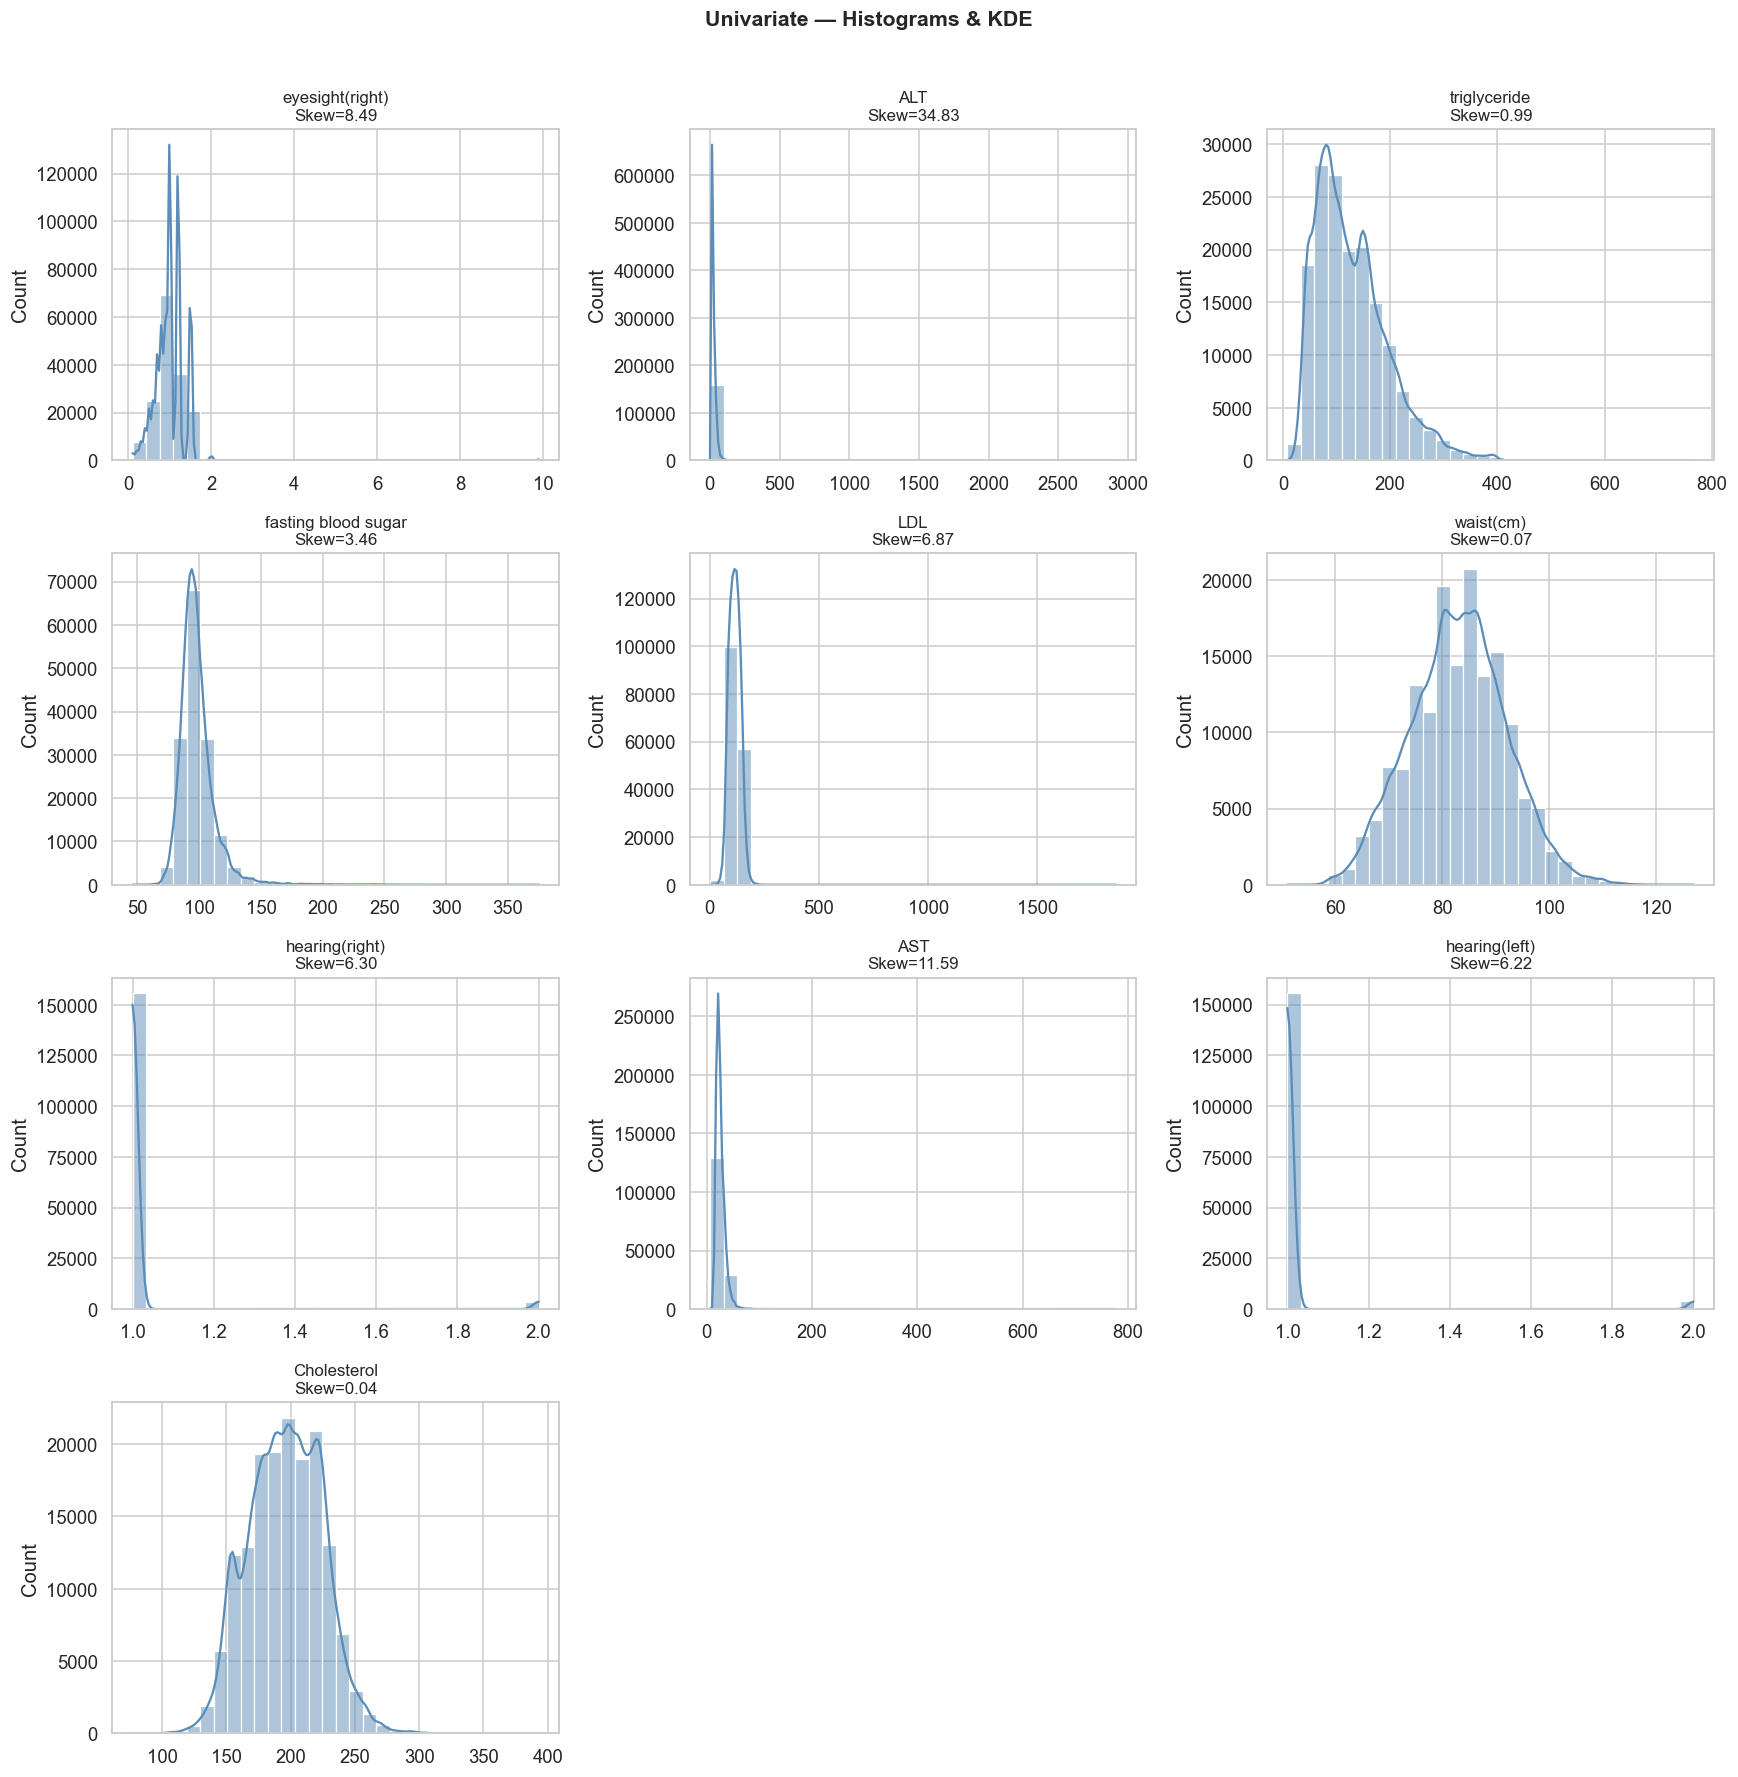

In [10]:
# ── 2.2  Histograms + KDE for all numerical features ─────────────────────────
n = len(num_features)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    sns.histplot(df[feat], kde=True, ax=axes[i], color="#5B8DB8", bins=30)
    axes[i].set_title(f"{feat}\nSkew={df[feat].skew():.2f}", fontsize=11)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate — Histograms & KDE", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_univariate_histograms.png", bbox_inches="tight")
plt.show()


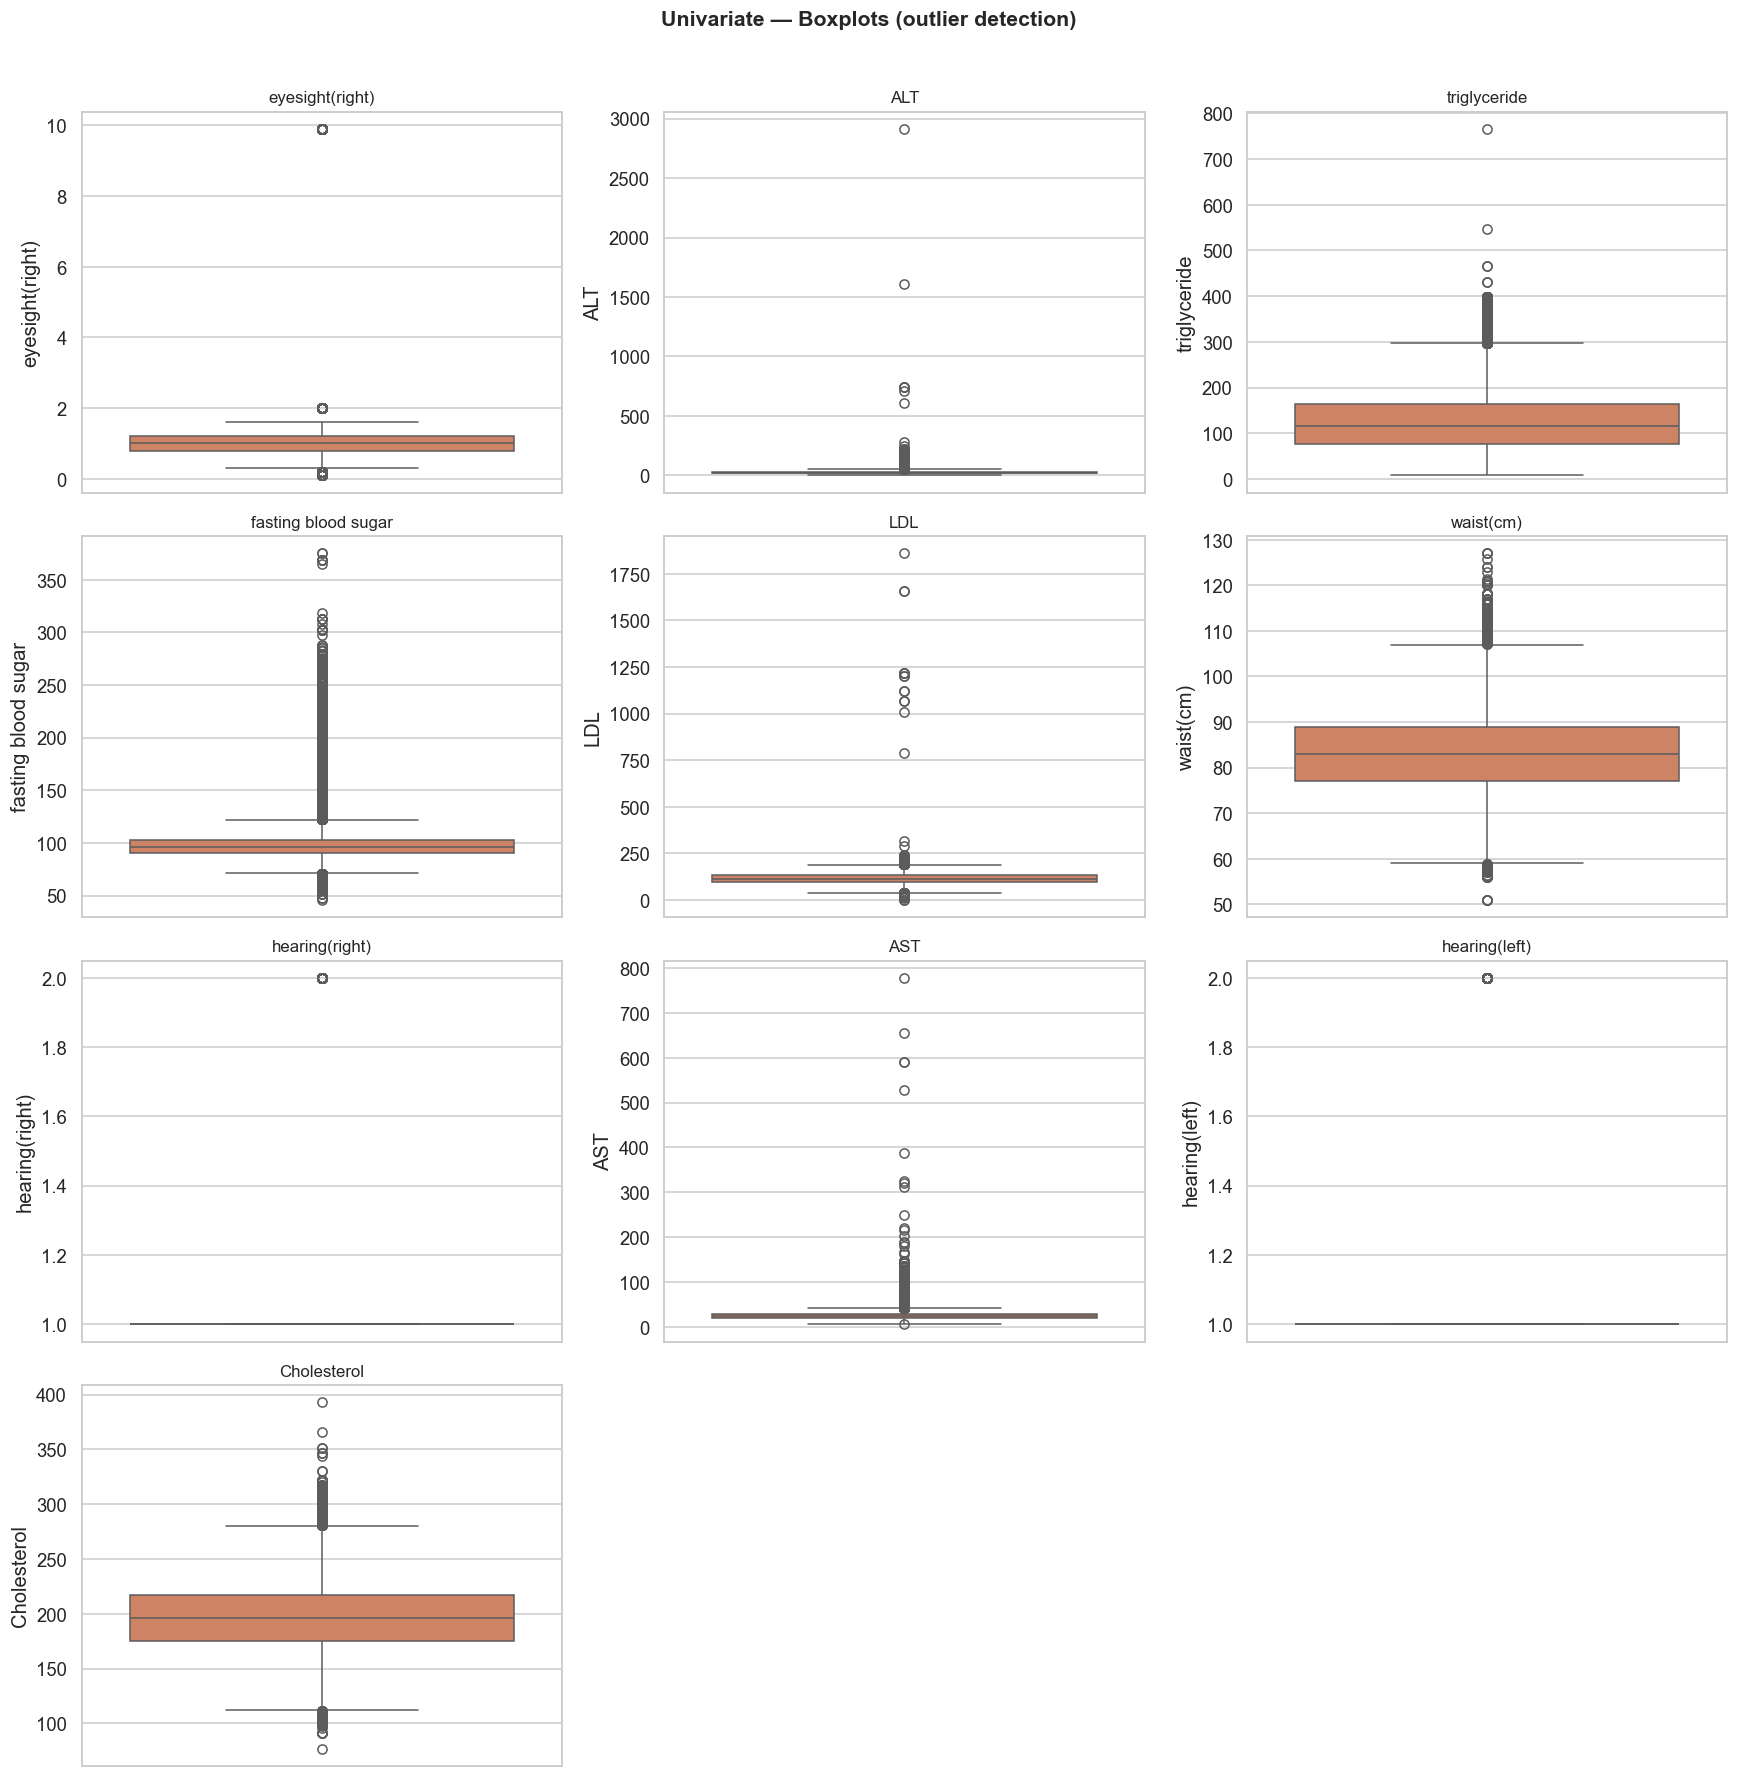

In [11]:
# ── 2.3  Boxplots to visualise spread and outliers ───────────────────────────
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    sns.boxplot(y=df[feat], ax=axes[i], color="#E07B54")
    axes[i].set_title(feat, fontsize=11)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate — Boxplots (outlier detection)", fontsize=14,
             y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_univariate_boxplots.png", bbox_inches="tight")
plt.show()


In [12]:
# ── 2.4  Outlier summary using IQR ───────────────────────────────────────────
outlier_summary = {}
for feat in num_features:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR     = Q3 - Q1
    n_out   = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    outlier_summary[feat] = {"Q1": round(Q1,2), "Q3": round(Q3,2),
                             "IQR": round(IQR,2), "Outliers": n_out,
                             "Outlier %": round(n_out/len(df)*100, 2)}

outlier_df = pd.DataFrame(outlier_summary).T.sort_values("Outliers", ascending=False)
print("Outlier Summary (IQR method):")
outlier_df


Outlier Summary (IQR method):


,Q1,Q3,IQR,Outliers,Outlier %
fasting blood sugar,90.0,103.0,13.0,8160.0,5.12
ALT,16.0,32.0,16.0,6746.0,4.24
AST,20.0,29.0,9.0,6337.0,3.98
hearing(left),1.0,1.0,0.0,3818.0,2.40
hearing(right),1.0,1.0,0.0,3730.0,2.34
triglyceride,77.0,165.0,88.0,3087.0,1.94
eyesight(right),0.8,1.2,0.4,2493.0,1.57
waist(cm),77.0,89.0,12.0,858.0,0.54
LDL,95.0,133.0,38.0,495.0,0.31
Cholesterol,175.0,217.0,42.0,430.0,0.27


In [13]:
# ── 2.5  Categorical features (if any) ───────────────────────────────────────
if cat_features:
    fig, axes = plt.subplots(1, len(cat_features),
                             figsize=(5*len(cat_features), 4))
    if len(cat_features) == 1:
        axes = [axes]
    for ax, feat in zip(axes, cat_features):
        df[feat].value_counts().plot(kind="bar", ax=ax, color="#7DB87D")
        ax.set_title(feat)
        ax.set_xlabel("")
    plt.suptitle("Univariate — Categorical Features", fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig_univariate_cat.png", bbox_inches="tight")
    plt.show()
else:
    print("No categorical features in this variant.")


No categorical features in this variant.


In [14]:
# ── 2.6  Normality test (Shapiro-Wilk on sample) ─────────────────────────────
print(f"{'Feature':<30} {'W-stat':>10} {'p-value':>12} {'Normal?':>10}")
print("-" * 65)
for feat in num_features:
    sample = df[feat].dropna().sample(min(500, len(df)), random_state=42)
    w, p   = stats.shapiro(sample)
    normal = "Yes" if p > 0.05 else "No"
    print(f"{feat:<30} {w:>10.4f} {p:>12.4e} {normal:>10}")


Feature                            W-stat      p-value    Normal?
-----------------------------------------------------------------
eyesight(right)                    0.9506   7.1867e-12         No
ALT                                0.8479   1.5622e-21         No
triglyceride                       0.9339   4.4559e-14         No
fasting blood sugar                0.8094   7.4487e-24         No
LDL                                0.9908   3.2432e-03         No
waist(cm)                          0.9974   6.3976e-01        Yes
hearing(right)                     0.0926   2.4537e-43         No
AST                                0.8605   1.1160e-20         No
hearing(left)                      0.1517   2.2760e-42         No
Cholesterol                        0.9938   3.8162e-02         No


## 3. Bivariate Analysis
Examining relationships between pairs of features, and each feature vs. the target.


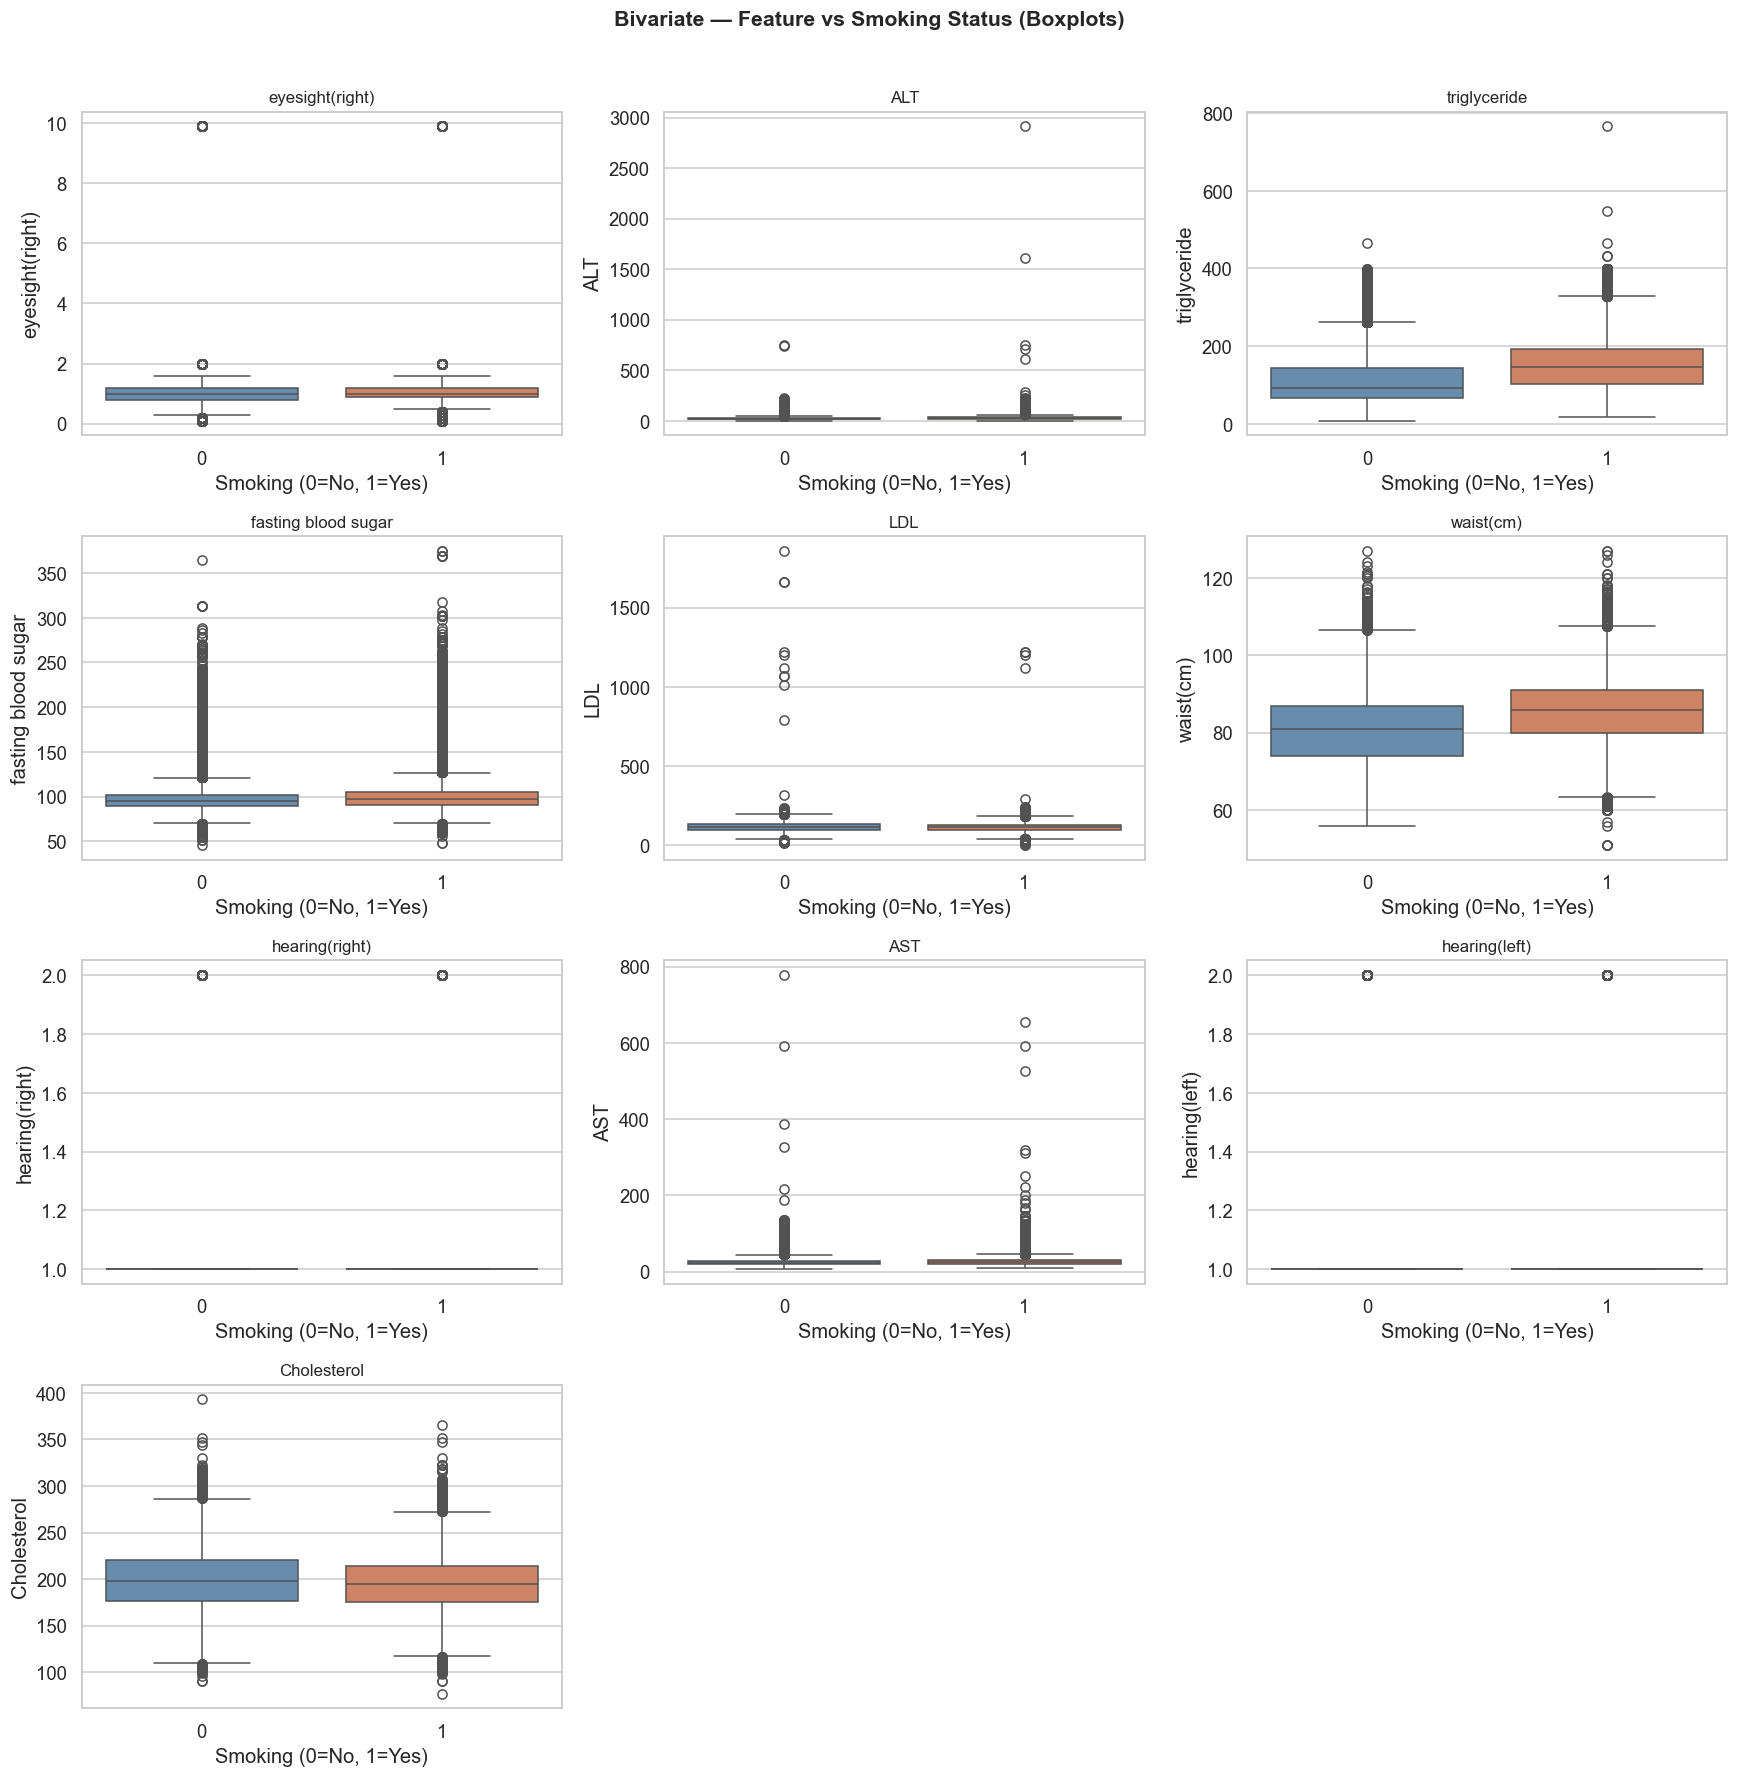

In [15]:
# ── 3.1  Feature vs Target — side-by-side boxplots ───────────────────────────
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    sns.boxplot(x="smoking", y=feat, data=df,
                palette=["#5B8DB8","#E07B54"], ax=axes[i])
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("Smoking (0=No, 1=Yes)")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Bivariate — Feature vs Smoking Status (Boxplots)",
             fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_bivariate_boxplots.png", bbox_inches="tight")
plt.show()


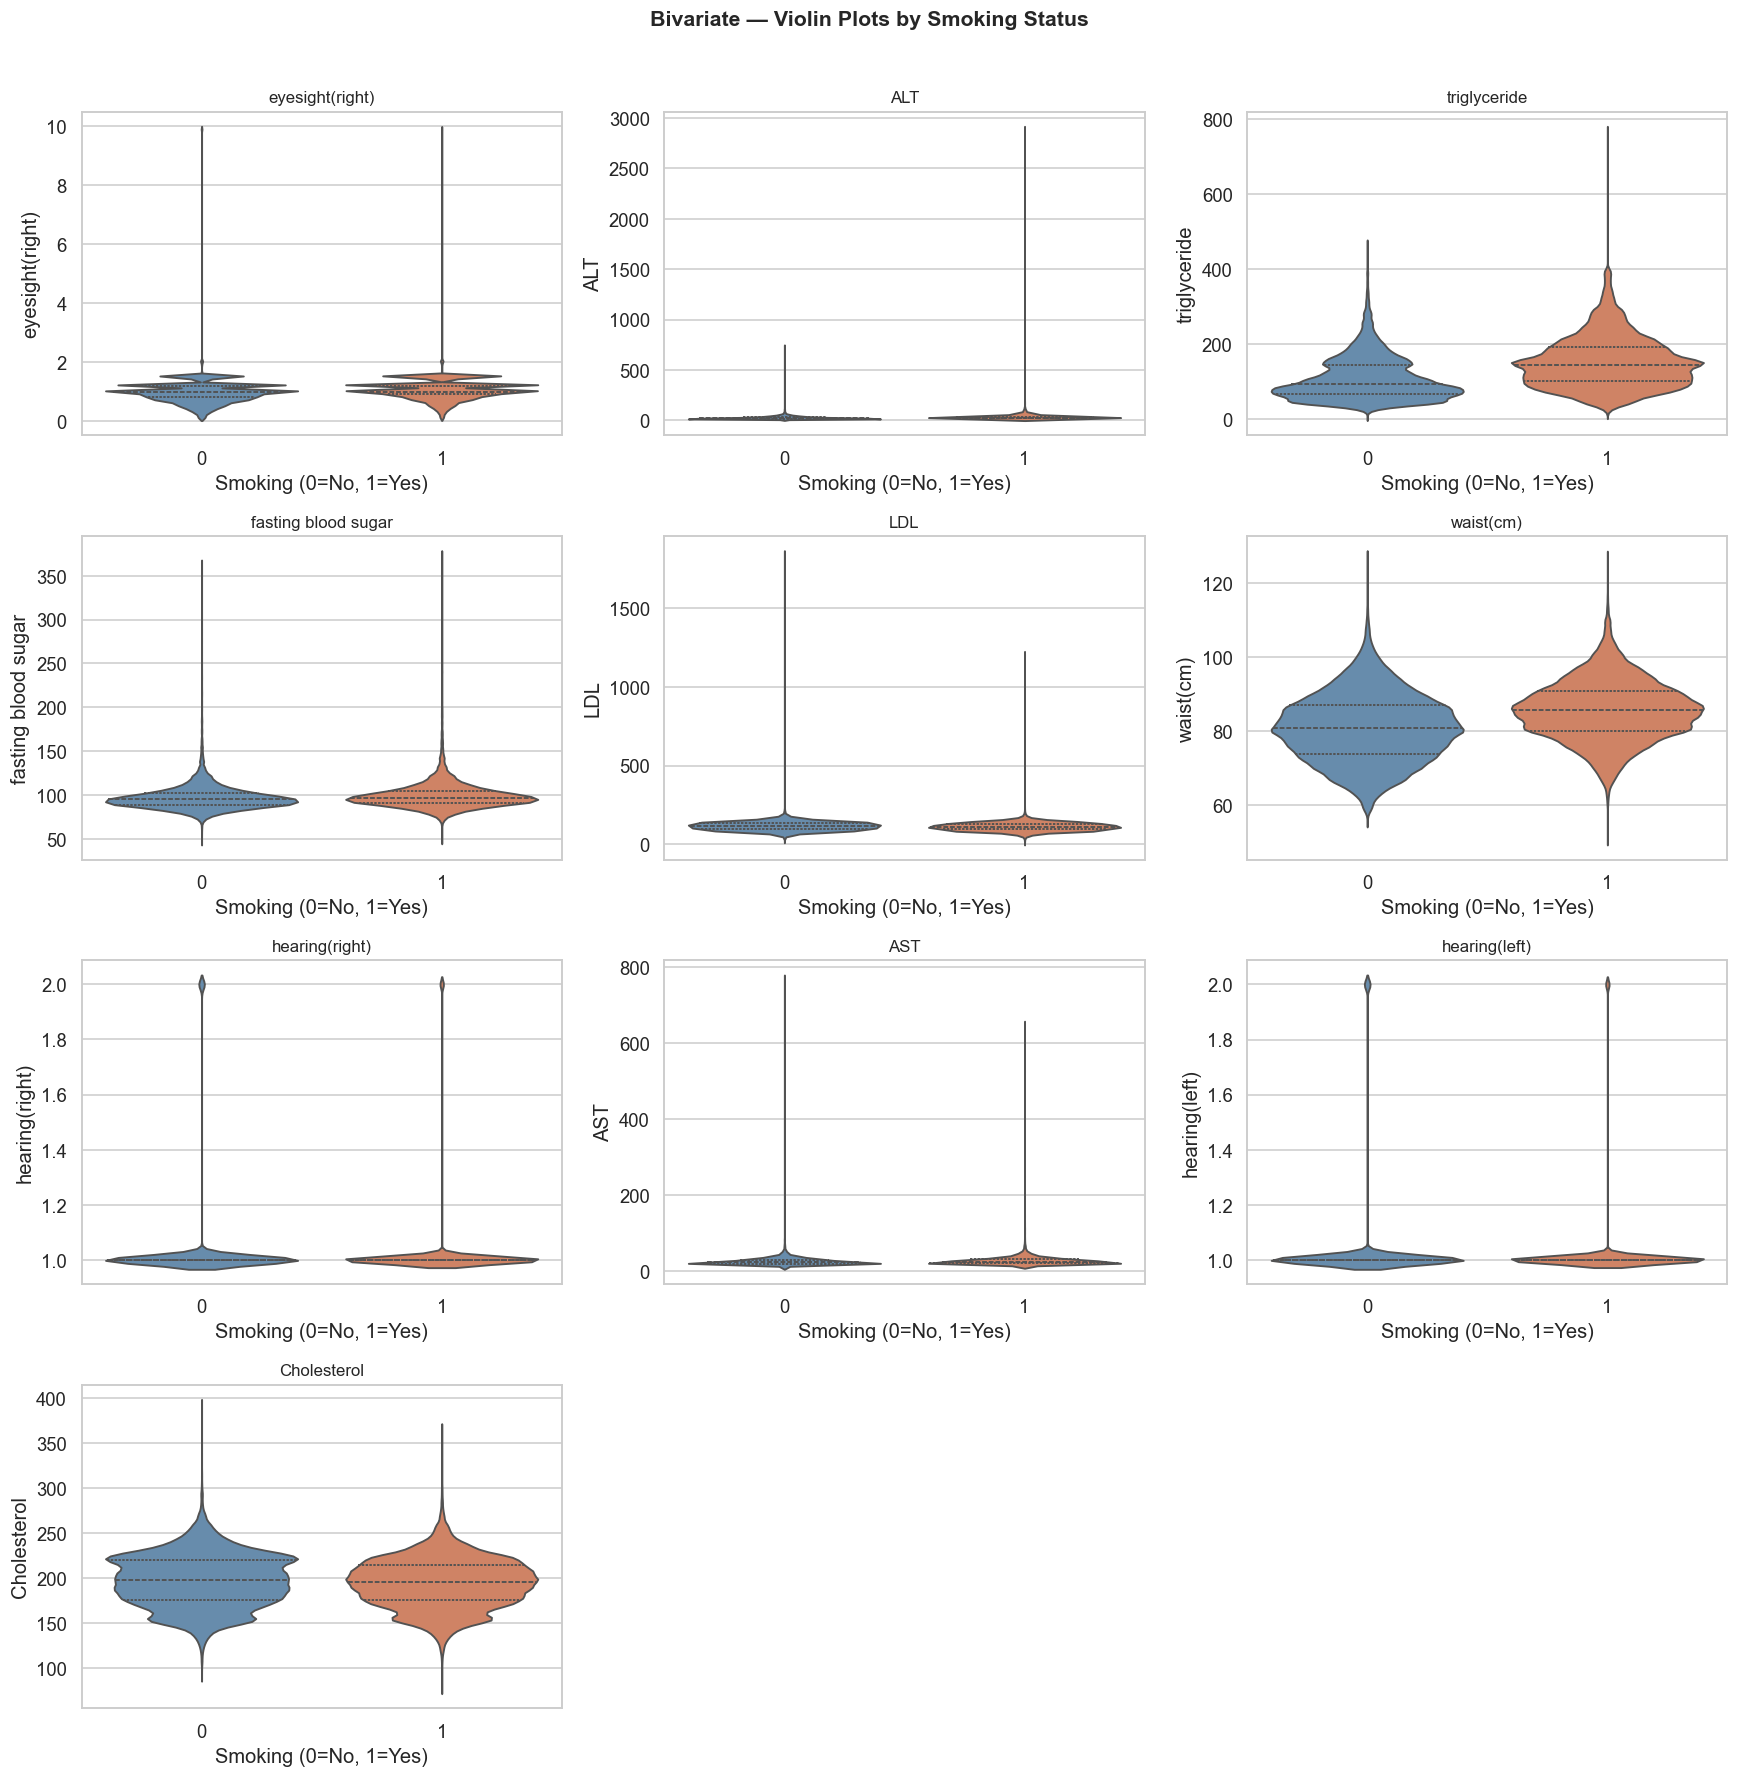

In [16]:
# ── 3.2  Violin plots — richer view of distribution per class ────────────────
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    sns.violinplot(x="smoking", y=feat, data=df,
                   palette=["#5B8DB8","#E07B54"], ax=axes[i], inner="quartile")
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("Smoking (0=No, 1=Yes)")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Bivariate — Violin Plots by Smoking Status",
             fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_bivariate_violins.png", bbox_inches="tight")
plt.show()


In [17]:
# ── 3.3  Point-biserial correlation: numerical features vs binary target ──────
from scipy.stats import pointbiserialr

corr_results = {}
for feat in num_features:
    corr, pval = pointbiserialr(df[feat].dropna(), df.loc[df[feat].notna(), "smoking"])
    corr_results[feat] = {"Correlation": round(corr, 4), "p-value": round(pval, 4),
                          "Significant": "" if pval < 0.05 else "Not Significant"}

corr_df = pd.DataFrame(corr_results).T.sort_values("Correlation", key=abs, ascending=False)
print("Point-Biserial Correlation with Smoking:")
print(corr_df.to_string())


Point-Biserial Correlation with Smoking:
                    Correlation p-value Significant
triglyceride              0.332     0.0            
waist(cm)                0.2627     0.0            
ALT                       0.163     0.0            
eyesight(right)          0.1098     0.0            
fasting blood sugar      0.0965     0.0            
LDL                     -0.0723     0.0            
AST                      0.0594     0.0            
Cholesterol             -0.0519     0.0            
hearing(left)           -0.0382     0.0            
hearing(right)          -0.0369     0.0            


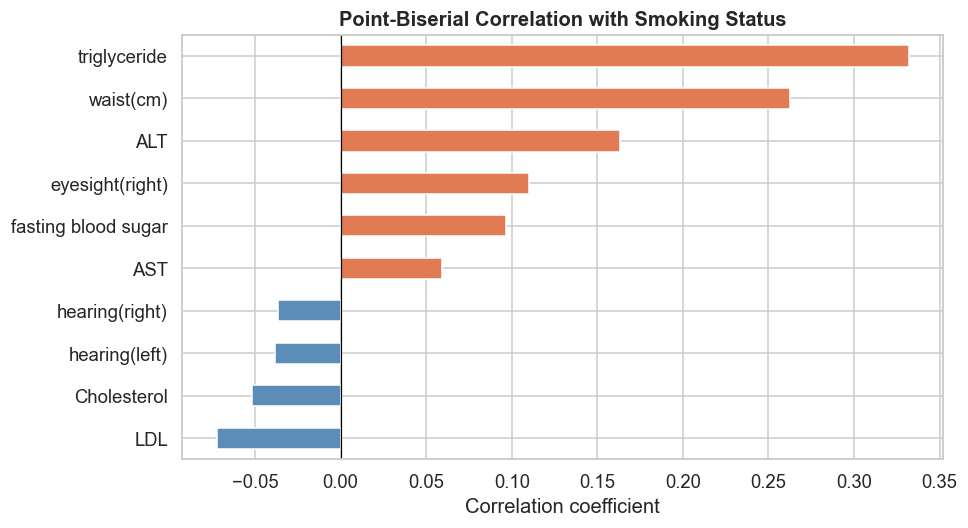

In [18]:
# ── 3.4  Correlation bar chart ────────────────────────────────────────────────
corr_vals = corr_df["Correlation"].astype(float).sort_values()
colors     = ["#E07B54" if v > 0 else "#5B8DB8" for v in corr_vals]

plt.figure(figsize=(9, 5))
corr_vals.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Point-Biserial Correlation with Smoking Status", fontweight="bold")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.savefig("fig_bivariate_correlation_bar.png", bbox_inches="tight")
plt.show()


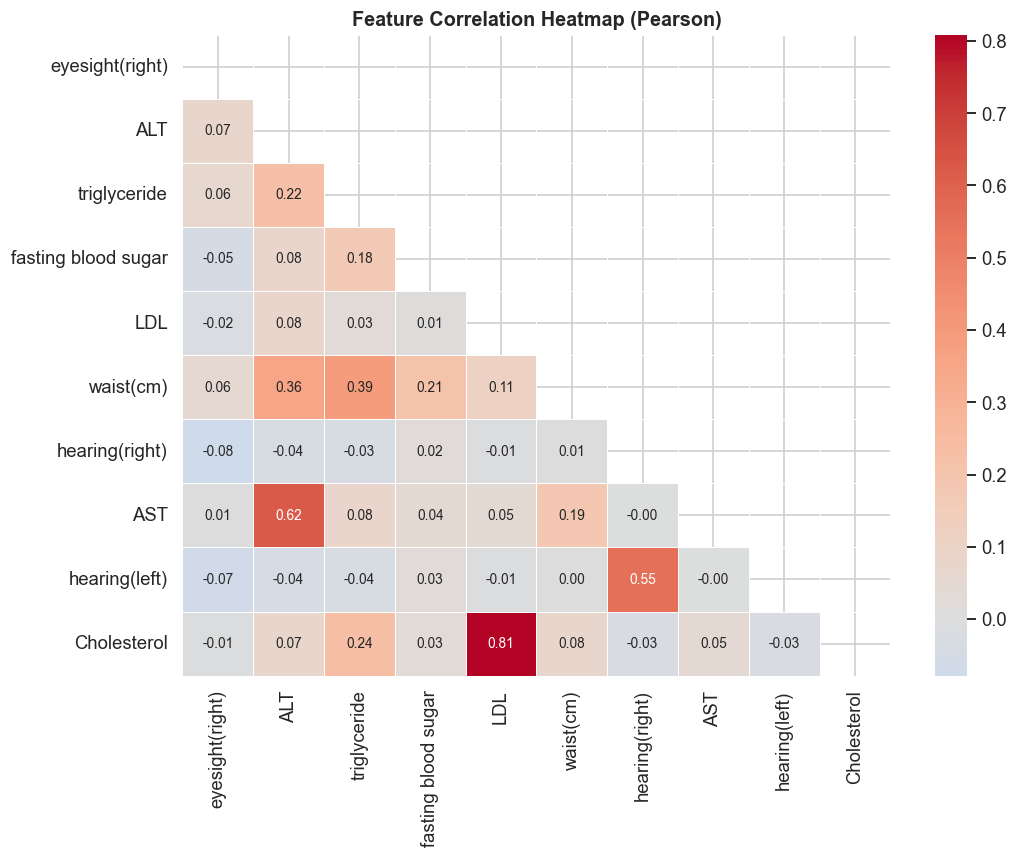

In [19]:
# ── 3.5  Pearson Correlation Heatmap (features only) ─────────────────────────
plt.figure(figsize=(10, 8))
corr_matrix = df[num_features].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 9})

plt.title("Feature Correlation Heatmap (Pearson)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_bivariate_heatmap.png", bbox_inches="tight")
plt.show()


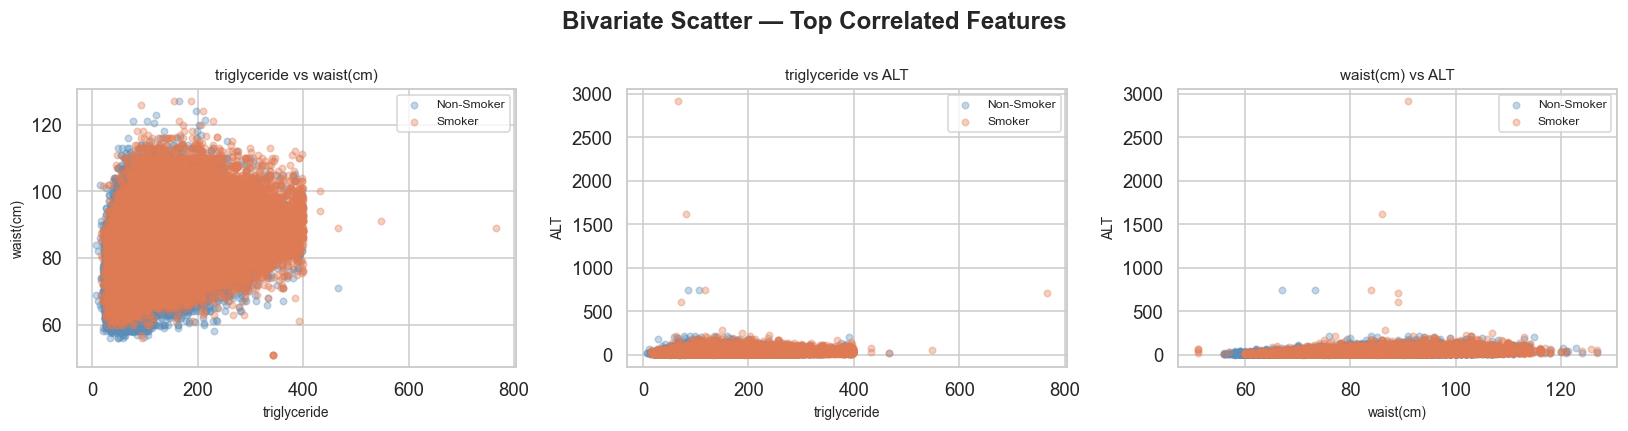

In [20]:
# ── 3.6  Scatter plots — top 3 correlated features vs each other ─────────────
top3 = corr_df.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [(top3[0], top3[1]), (top3[0], top3[2]), (top3[1], top3[2])]

for ax, (fx, fy) in zip(axes, pairs):
    for cls, color, label in [(0,"#5B8DB8","Non-Smoker"), (1,"#E07B54","Smoker")]:
        sub = df[df["smoking"] == cls]
        ax.scatter(sub[fx], sub[fy], alpha=0.35, s=18,
                   color=color, label=label)
    ax.set_xlabel(fx, fontsize=9)
    ax.set_ylabel(fy, fontsize=9)
    ax.set_title(f"{fx} vs {fy}", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Bivariate Scatter — Top Correlated Features", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_bivariate_scatter.png", bbox_inches="tight")
plt.show()


## 4. Multivariate Analysis
Assessing complex interactions among multiple features simultaneously.


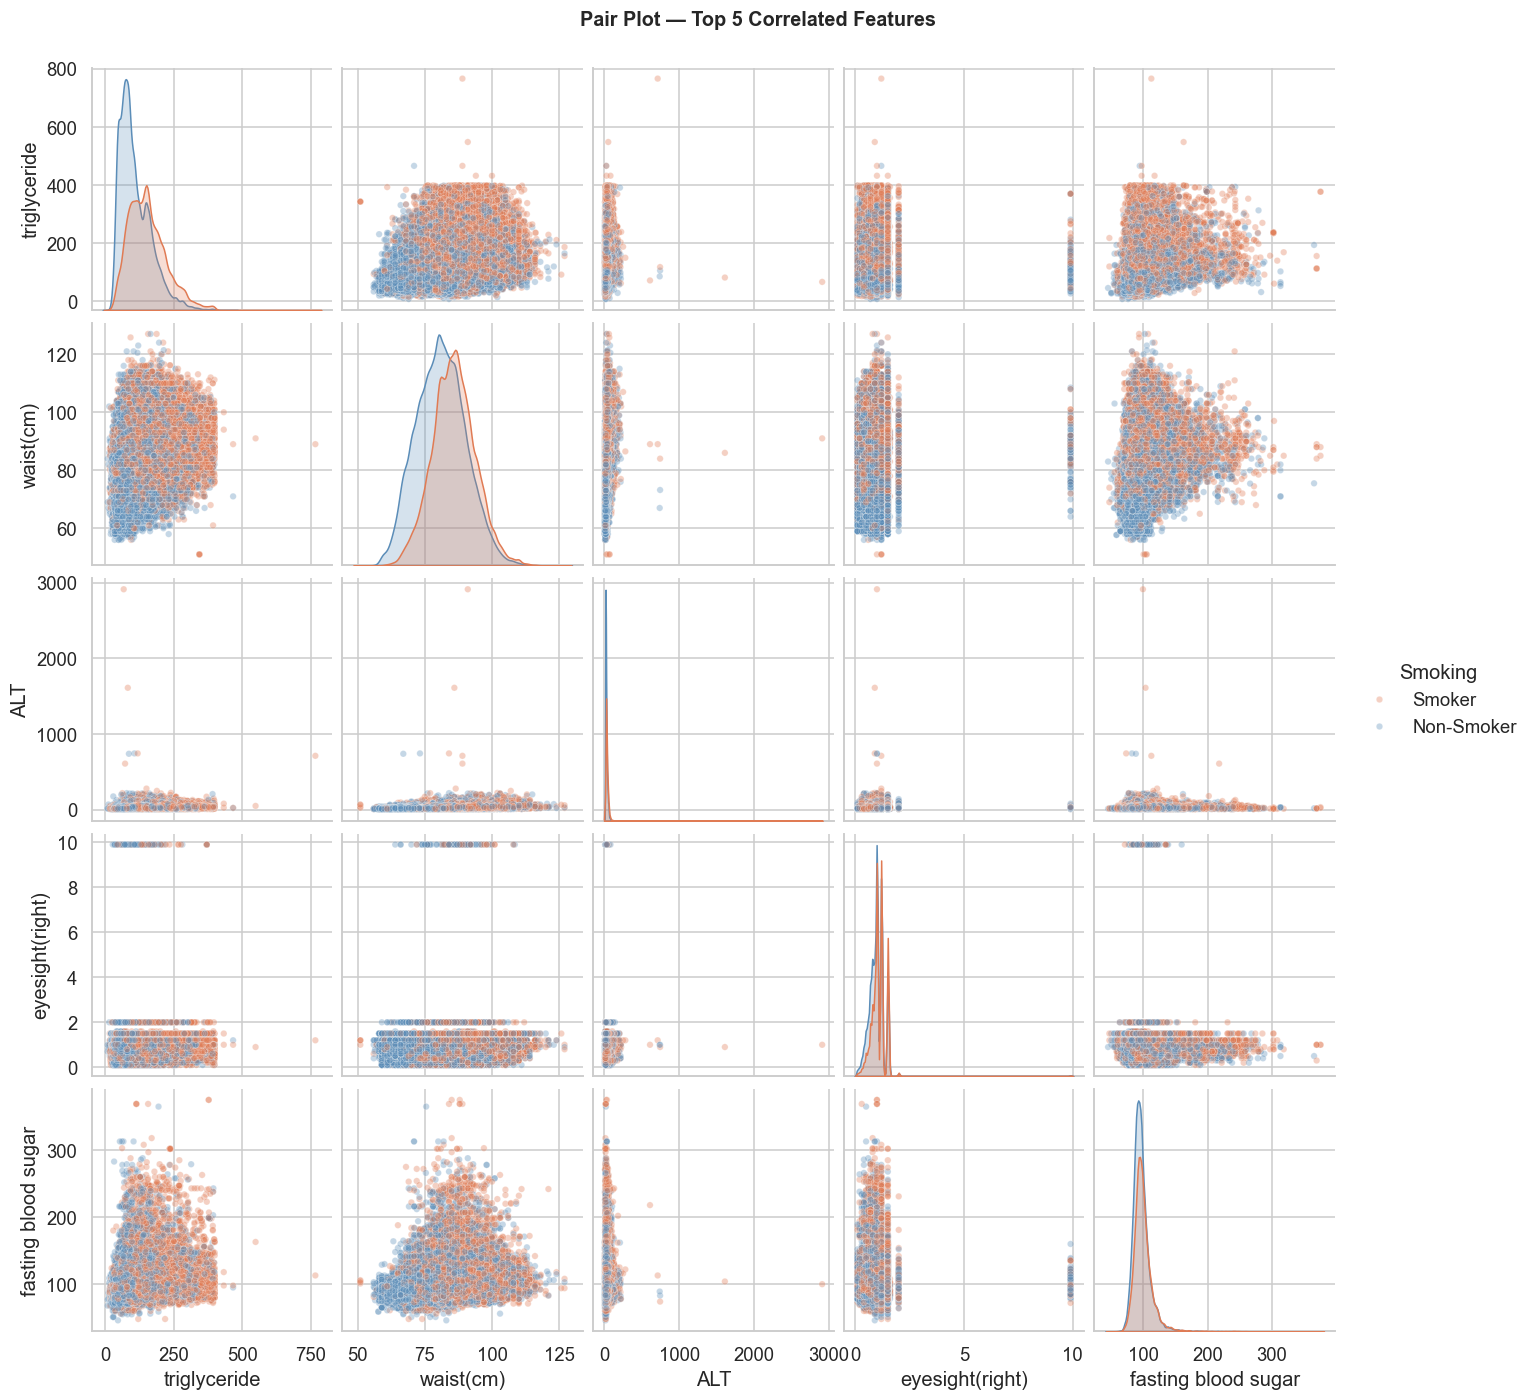

In [21]:
# ── 4.1  Pair Plot (top 5 most correlated features) ──────────────────────────
top5 = corr_df.head(5).index.tolist()
pair_df = df[top5 + ["smoking"]].copy()
pair_df["Smoking"] = pair_df["smoking"].map({0:"Non-Smoker", 1:"Smoker"})

g = sns.pairplot(pair_df.drop(columns="smoking"),
                 hue="Smoking", plot_kws={"alpha": 0.35, "s": 18},
                 palette={"Non-Smoker":"#5B8DB8", "Smoker":"#E07B54"})
g.fig.suptitle("Pair Plot — Top 5 Correlated Features", y=1.02,
               fontsize=13, fontweight="bold")
g.fig.savefig("fig_multivariate_pairplot.png", bbox_inches="tight")
plt.show()


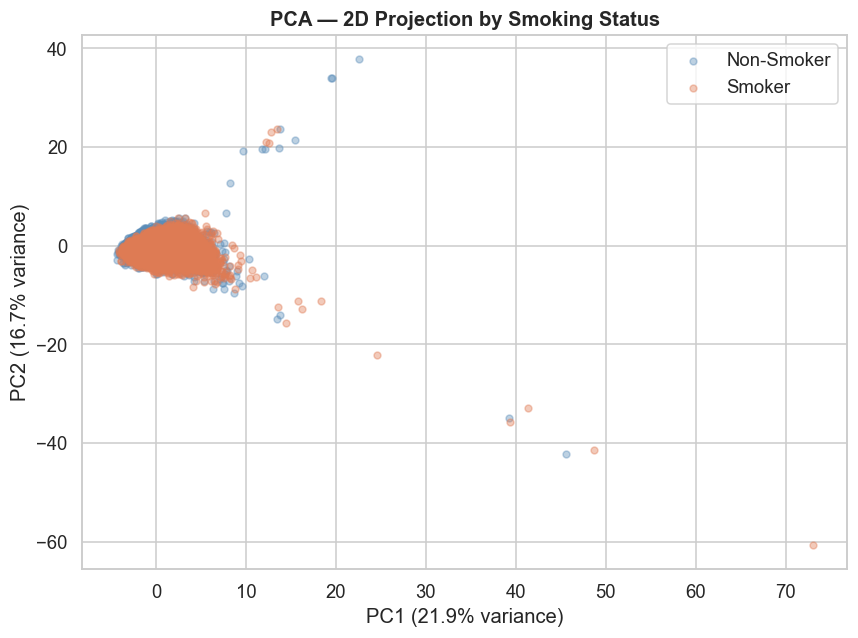

Total variance explained by PC1+PC2: 38.6%


In [22]:
# ── 4.2  PCA — 2D projection ──────────────────────────────────────────────────
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df[num_features].fillna(df[num_features].median()))

pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for cls, color, label in [(0,"#5B8DB8","Non-Smoker"), (1,"#E07B54","Smoker")]:
    mask = df["smoking"] == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                alpha=0.4, s=20, color=color, label=label)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA — 2D Projection by Smoking Status", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("fig_multivariate_pca.png", bbox_inches="tight")
plt.show()

print(f"Total variance explained by PC1+PC2: "
      f"{sum(pca.explained_variance_ratio_[:2])*100:.1f}%")


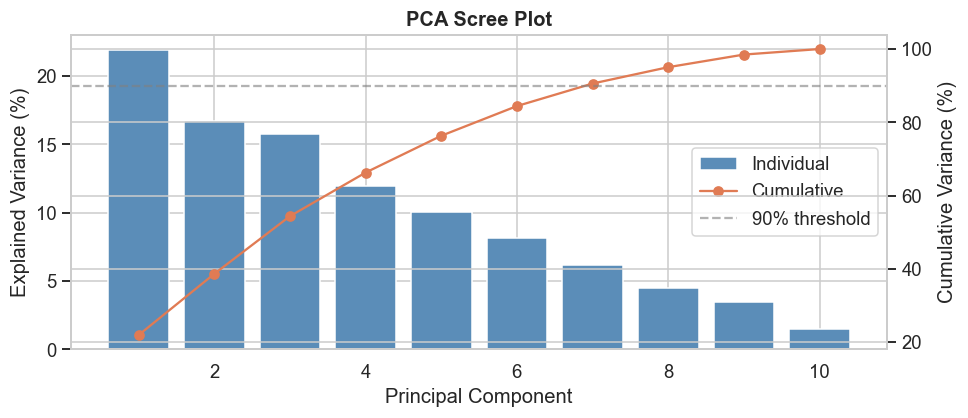

In [23]:
# ── 4.3  PCA Scree plot ───────────────────────────────────────────────────────
pca_full  = PCA(random_state=42)
pca_full.fit(X_scaled)
exp_var   = pca_full.explained_variance_ratio_
cum_var   = np.cumsum(exp_var)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(range(1, len(exp_var)+1), exp_var*100, color="#5B8DB8", label="Individual")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (%)")

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_var)+1), cum_var*100, "o-", color="#E07B54",
         label="Cumulative")
ax2.set_ylabel("Cumulative Variance (%)")
ax2.axhline(90, linestyle="--", color="gray", alpha=0.6, label="90% threshold")

plt.title("PCA Scree Plot", fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="center right")
plt.tight_layout()
plt.savefig("fig_multivariate_scree.png", bbox_inches="tight")
plt.show()


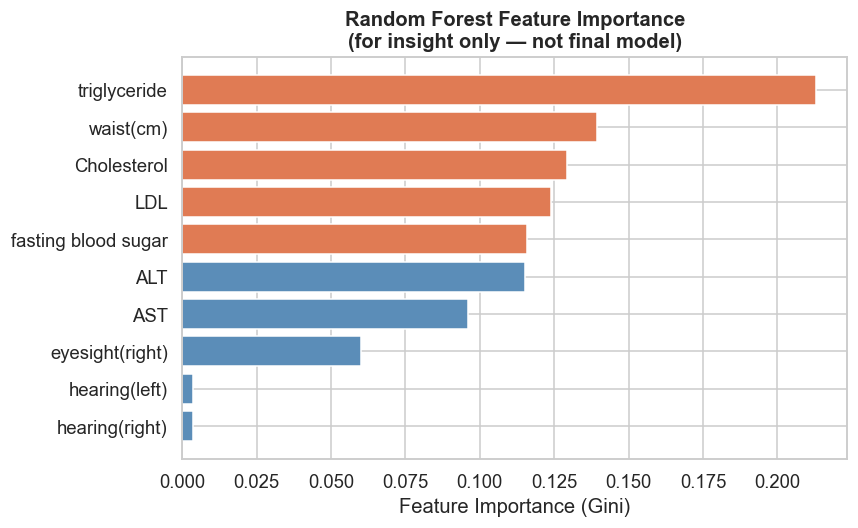


Top 5 most important features:
            Feature  Importance
       triglyceride    0.212929
          waist(cm)    0.139393
        Cholesterol    0.129303
                LDL    0.123824
fasting blood sugar    0.115968


In [24]:
# ── 4.4  Random Forest Feature Importance (insight only) ─────────────────────
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, df["smoking"])

importance_df = pd.DataFrame({
    "Feature":    num_features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
colors = ["#E07B54" if v > importance_df["Importance"].median()
          else "#5B8DB8" for v in importance_df["Importance"]]
plt.barh(importance_df["Feature"], importance_df["Importance"], color=colors)
plt.xlabel("Feature Importance (Gini)")
plt.title("Random Forest Feature Importance\n(for insight only — not final model)",
          fontweight="bold")
plt.tight_layout()
plt.savefig("fig_multivariate_rf_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
print(importance_df.sort_values("Importance", ascending=False).head().to_string(index=False))


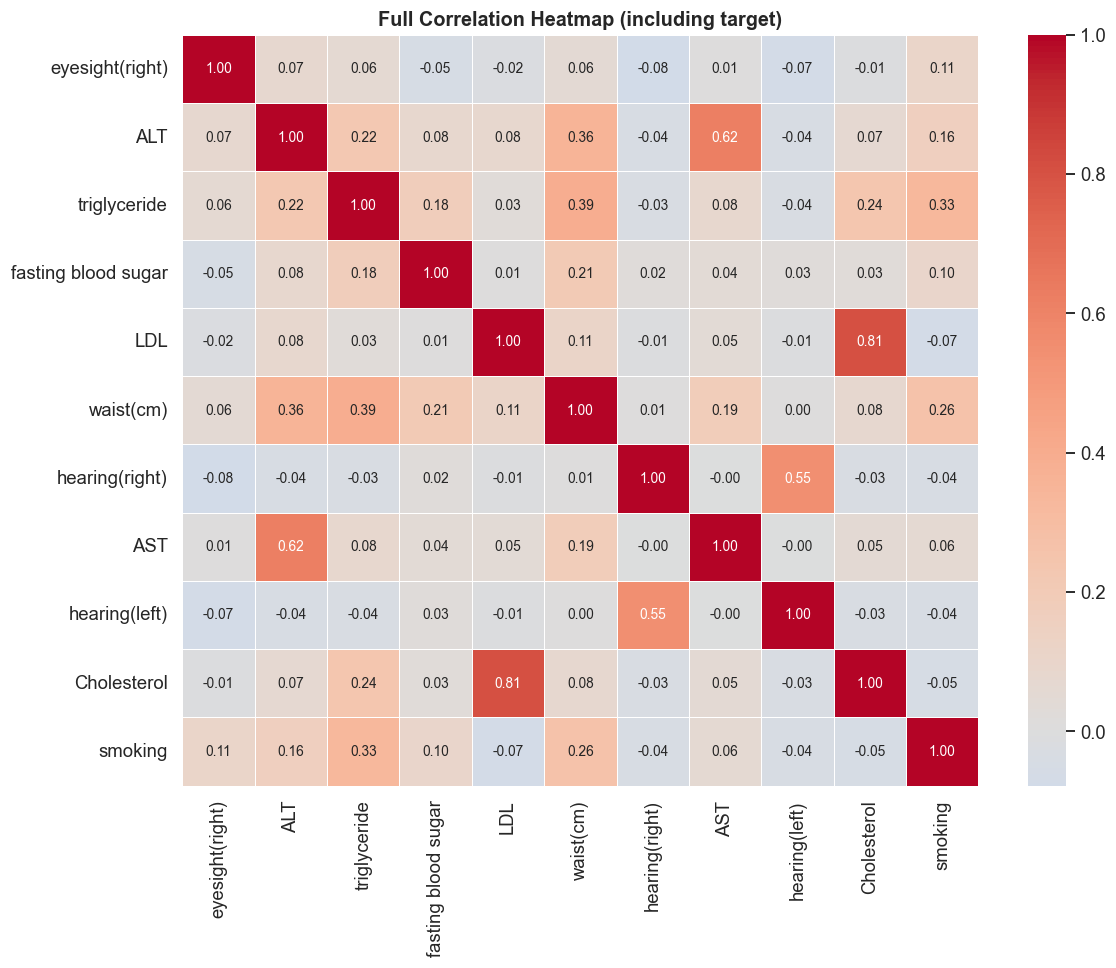

In [25]:
# ── 4.5  Full correlation heatmap including target ────────────────────────────
plt.figure(figsize=(11, 9))
full_corr = df[num_features + ["smoking"]].corr()

sns.heatmap(full_corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, linecolor="white",
            annot_kws={"size": 9})
plt.title("Full Correlation Heatmap (including target)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_multivariate_full_heatmap.png", bbox_inches="tight")
plt.show()


## 5. Analysis Summary & Handoff Notes for Person 2

In [26]:
print("=" * 65)
print("  ANALYSIS SUMMARY — HANDOFF TO PERSON 2 (Feature Engineering)")
print("=" * 65)

print("\n 1. SKEWED FEATURES (|skew| > 1) → consider log-transform:")
skewed = [(f, round(df[f].skew(), 2)) for f in num_features if abs(df[f].skew()) > 1]
for f, s in sorted(skewed, key=lambda x: abs(x[1]), reverse=True):
    print(f"   {f:<30}  skew = {s}")

print("\n 2. HIGH-OUTLIER FEATURES (>5% outliers by IQR):")
high_out = outlier_df[outlier_df["Outlier %"] > 5]
print(high_out[["Outliers","Outlier %"]].to_string())

print("\n 3. MOST CORRELATED WITH TARGET (|r| > 0.05):")
top_corr = corr_df[corr_df["Correlation"].astype(float).abs() > 0.05]
print(top_corr[["Correlation","p-value","Significant"]].to_string())

print("\n 4. HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7) → possible redundancy:")
high_pairs = []
for i in range(len(num_features)):
    for j in range(i+1, len(num_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_pairs.append((num_features[i], num_features[j], round(r, 3)))
if high_pairs:
    for f1, f2, r in high_pairs:
        print(f"   {f1} <-> {f2}  r = {r}")
else:
    print("   None found above 0.7 threshold.")

print("\n 5. RECOMMENDED ACTIONS FOR FEATURE ENGINEERING:")
print("   • Apply StandardScaler (or MinMaxScaler) to all numerical features")
print("   • Remove outliers using IQR method on high-outlier features")
print("   • Log-transform heavily skewed features")
print("   • Check class balance — apply SMOTE if imbalanced")
print("\n Split files ready: train.csv, val.csv, test.csv")


  ANALYSIS SUMMARY — HANDOFF TO PERSON 2 (Feature Engineering)

 1. SKEWED FEATURES (|skew| > 1) → consider log-transform:
   ALT                             skew = 34.83
   AST                             skew = 11.59
   eyesight(right)                 skew = 8.49
   LDL                             skew = 6.87
   hearing(right)                  skew = 6.3
   hearing(left)                   skew = 6.22
   fasting blood sugar             skew = 3.46

 2. HIGH-OUTLIER FEATURES (>5% outliers by IQR):
                     Outliers  Outlier %
fasting blood sugar    8160.0       5.12

 3. MOST CORRELATED WITH TARGET (|r| > 0.05):
                    Correlation p-value Significant
triglyceride              0.332     0.0            
waist(cm)                0.2627     0.0            
ALT                       0.163     0.0            
eyesight(right)          0.1098     0.0            
fasting blood sugar      0.0965     0.0            
LDL                     -0.0723     0.0            
AST 